# tasks W-02

In [1]:
import numpy as np
import pandas as pd
pd.options.mode.chained_assignment = None 
import pickle

import os
from importlib import reload

import matplotlib.pyplot as plt
import matplotlib 
# import seaborn as sns
%matplotlib inline
plt.style.use('ggplot')
from matplotlib.ticker import MultipleLocator

### load data

In [2]:
df_comp_details = pd.read_csv('duopoly_competition_details.csv')
df_comp_details.fillna(0, inplace=True)
df_comp_details.head(3)

,competition_id,selling_season,selling_period,competitor_id,price_competitor,price,demand,competitor_has_capacity,calculation_duration,errors
0,3HmCSH,1,1,SaffronDolphin,56.1,66.4,0,True,0.005,0.0
1,3HmCSH,1,2,SaffronDolphin,66.4,66.4,0,True,0.006,0.0
2,3HmCSH,1,3,SaffronDolphin,66.4,66.4,0,True,0.007,0.0


## (1) find based on your own competition details CSV the best (max revenue) capacity utilization curve

### (a) compute the revenue for all selling_seasons and competitions

In [3]:
df_comp_details['revenue'] =  """ADD CODE HERE"""
df_comp_details.tail(5)

,competition_id,selling_season,selling_period,competitor_id,price_competitor,price,demand,competitor_has_capacity,calculation_duration,errors,revenue
39995,rPaVZC,100,96,AttentiveOriole,13.5,13.7,3,False,0.004,0.0,41.1
39996,rPaVZC,100,97,AttentiveOriole,13.7,13.7,0,False,0.004,0.0,0.0
39997,rPaVZC,100,98,AttentiveOriole,13.7,13.7,0,False,0.004,0.0,0.0
39998,rPaVZC,100,99,AttentiveOriole,13.7,13.7,0,False,0.004,0.0,0.0
39999,rPaVZC,100,100,AttentiveOriole,13.7,13.7,0,False,0.005,0.0,0.0


In [4]:
df_comp_details['unique_selling_season_key'] = """ADD CODE HERE"""  
df_comp_details.head(2)

,competition_id,selling_season,selling_period,competitor_id,price_competitor,price,demand,competitor_has_capacity,calculation_duration,errors,revenue,unique_selling_season_key
0,3HmCSH,1,1,SaffronDolphin,56.1,66.4,0,True,0.005,0.0,0.0,3HmCSH_1
1,3HmCSH,1,2,SaffronDolphin,66.4,66.4,0,True,0.006,0.0,0.0,3HmCSH_1


In [5]:
dfx_rev = df_comp_details.groupby('unique_selling_season_key').agg({
    'revenue' : 'sum'
}).reset_index()
dfx_rev

,unique_selling_season_key,revenue
0,3HmCSH_1,363.7
1,3HmCSH_10,1266.4
2,3HmCSH_100,399.7
3,3HmCSH_11,1652.7
4,3HmCSH_12,1572.3
...,...,...
395,rPaVZC_95,2844.8
396,rPaVZC_96,1784.6
397,rPaVZC_97,4376.1
398,rPaVZC_98,2629.0


array([[<Axes: title={'center': 'revenue'}>]], dtype=object)

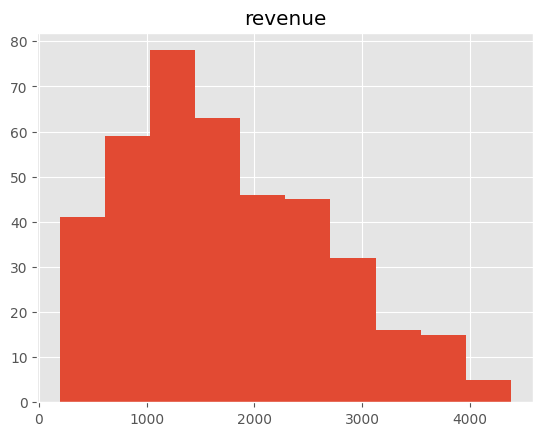

In [6]:
dfx_rev.hist()

In [7]:
dfx_rev.describe()

,revenue
count,400.000000
mean,1740.731250
std,939.469504
min,196.900000
25%,1034.900000
50%,1570.350000
75%,2401.250000
max,4376.100000


### get the selling season keys with the top 20% revenue generation

In [8]:
dfx_rev.quantile(0.8)

/tmp/ipykernel_705/3896314509.py:1: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  dfx_rev.quantile(0.8)


revenue    2573.22
Name: 0.8, dtype: float64

In [9]:
top_selling_seasons = dfx_rev[   """ADD CODE HERE"""   ].unique_selling_season_key.unique()
top_selling_seasons[:10]

array(['3UDGYU_57', '3UDGYU_96', 'bh2y6f_1', 'bh2y6f_11', 'bh2y6f_14',
       'bh2y6f_15', 'bh2y6f_19', 'bh2y6f_21', 'bh2y6f_22', 'bh2y6f_23'],
      dtype=object)

In [10]:
# quick double check
dfx_rev[dfx_rev.unique_selling_season_key.isin(top_selling_seasons)].revenue.mean()

3188.67

### (b) compute the capacity utilization curves per selling season

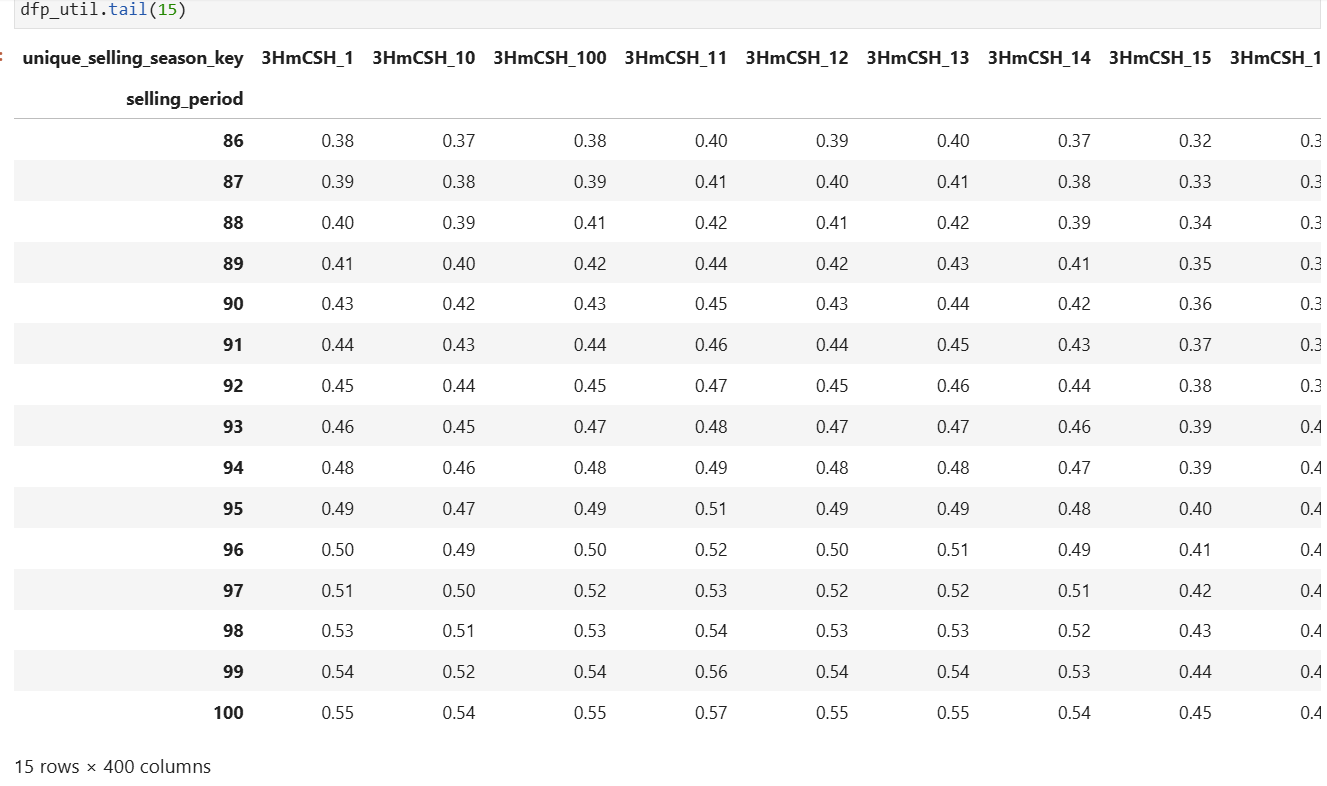

In [11]:
dfp_util = pd.pivot_table(df_comp_details, 
                        """ADD CODE HERE"""
)
  
dfp_util.tail()

unique_selling_season_key,3HmCSH_1,3HmCSH_10,3HmCSH_100,3HmCSH_11,3HmCSH_12,3HmCSH_13,3HmCSH_14,3HmCSH_15,3HmCSH_16,3HmCSH_17,...,rPaVZC_90,rPaVZC_91,rPaVZC_92,rPaVZC_93,rPaVZC_94,rPaVZC_95,rPaVZC_96,rPaVZC_97,rPaVZC_98,rPaVZC_99
selling_period,,,,,,,,,,,,,,,,,,,,,
96,0,0,0,3,0,0,0,1,3,3,...,2,0,0,1,4,0,0,0,1,1
97,0,2,0,1,0,1,0,1,3,1,...,1,2,3,1,3,0,3,0,0,1
98,0,0,0,0,0,4,0,2,2,0,...,1,2,3,3,1,0,1,0,0,0
99,0,0,0,0,0,0,0,0,1,0,...,1,2,3,0,0,1,4,0,0,0
100,0,1,0,0,0,2,0,1,1,0,...,0,0,3,0,0,1,1,0,0,0


#### compute the utilization fractions

In [27]:
for c in dfp_util.columns:
    dfp_util[c] = dfp_util[c].cumsum()
    dfp_util[c] = round(dfp_util[c] / 80, 2)
    
dfp_util.tail(15)

unique_selling_season_key,3HmCSH_1,3HmCSH_10,3HmCSH_100,3HmCSH_11,3HmCSH_12,3HmCSH_13,3HmCSH_14,3HmCSH_15,3HmCSH_16,3HmCSH_17,...,rPaVZC_90,rPaVZC_91,rPaVZC_92,rPaVZC_93,rPaVZC_94,rPaVZC_95,rPaVZC_96,rPaVZC_97,rPaVZC_98,rPaVZC_99
selling_period,,,,,,,,,,,,,,,,,,,,,
86,0.38,0.37,0.38,0.40,0.39,0.40,0.37,0.32,0.33,0.38,...,0.38,0.36,0.36,0.35,0.31,0.38,0.33,0.40,0.38,0.38
87,0.39,0.38,0.39,0.41,0.40,0.41,0.38,0.33,0.34,0.39,...,0.39,0.37,0.37,0.36,0.32,0.39,0.34,0.41,0.39,0.39
88,0.40,0.39,0.41,0.42,0.41,0.42,0.39,0.34,0.35,0.40,...,0.40,0.38,0.38,0.37,0.33,0.40,0.34,0.42,0.40,0.40
89,0.41,0.40,0.42,0.44,0.42,0.43,0.41,0.35,0.36,0.41,...,0.41,0.39,0.39,0.38,0.34,0.41,0.35,0.43,0.42,0.41
90,0.43,0.42,0.43,0.45,0.43,0.44,0.42,0.36,0.37,0.42,...,0.42,0.40,0.40,0.39,0.35,0.42,0.36,0.45,0.43,0.42
91,0.44,0.43,0.44,0.46,0.44,0.45,0.43,0.37,0.38,0.43,...,0.43,0.41,0.41,0.40,0.36,0.43,0.37,0.46,0.44,0.43
92,0.45,0.44,0.45,0.47,0.45,0.46,0.44,0.38,0.39,0.45,...,0.44,0.42,0.43,0.41,0.37,0.44,0.38,0.47,0.45,0.45
93,0.46,0.45,0.47,0.48,0.47,0.47,0.46,0.39,0.40,0.46,...,0.45,0.44,0.44,0.42,0.38,0.46,0.39,0.48,0.46,0.46
94,0.48,0.46,0.48,0.49,0.48,0.48,0.47,0.39,0.41,0.47,...,0.46,0.45,0.45,0.43,0.40,0.47,0.40,0.49,0.48,0.47


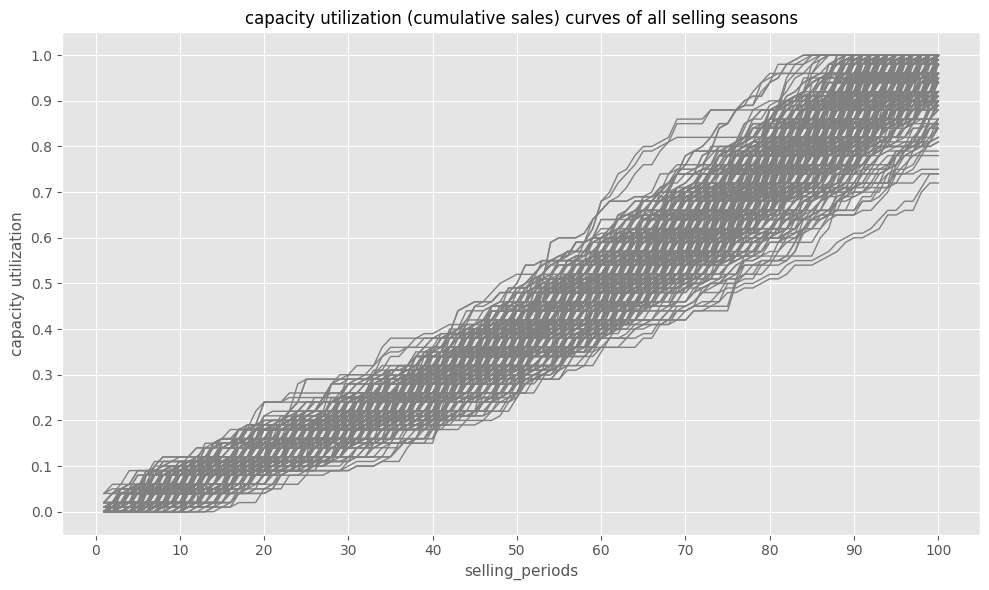

In [13]:
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(dfp_util.index, dfp_util, color='grey', 
        linestyle='-', linewidth=1, )
ax.set_xlabel('selling_periods', size=11)
# ax.set_xticks(np.arange(min(dft.index), max(dft.index)+1, 1.0))
ax.set_ylabel("capacity utilization" , size=11)

y_majorLocator = MultipleLocator(0.1)
ax.yaxis.set_major_locator(y_majorLocator)
x_majorLocator = MultipleLocator(10)
ax.xaxis.set_major_locator(x_majorLocator)

ax.set_title("capacity utilization (cumulative sales) curves of all selling seasons", size=12)
# ax.legend(loc=0)

ax.grid(True)
fig.tight_layout()

plt.show()

### show only the top revenue curves

In [14]:
dfp_top_curves = dfp_util[   """ADD CODE HERE"""   ]
dfp_top_curves.shape

(100, 80)

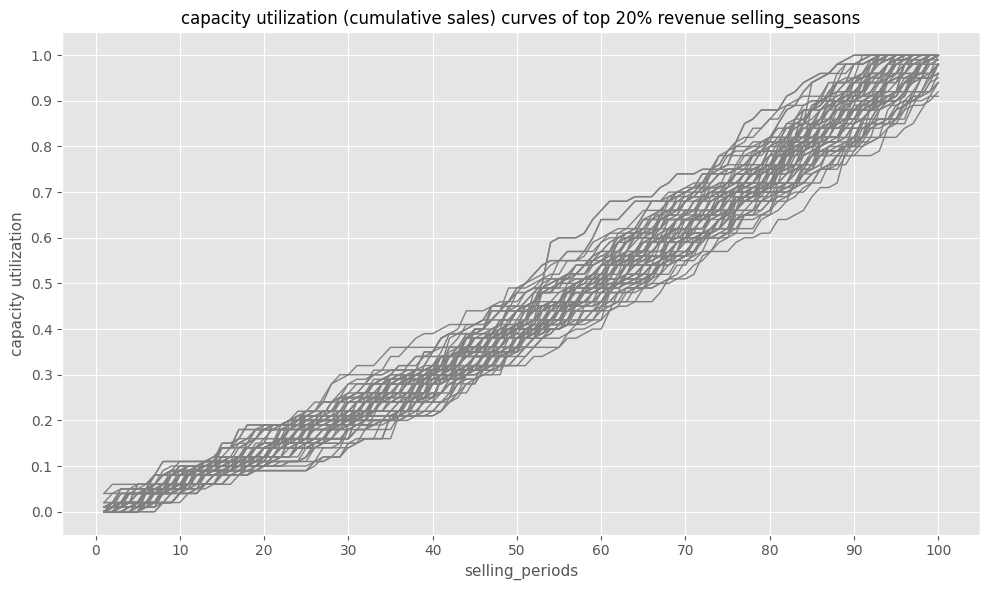

In [15]:
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(dfp_top_curves.index, dfp_top_curves, color='grey', 
        linestyle='-', linewidth=1, )
ax.set_xlabel('selling_periods', size=11)
# ax.set_xticks(np.arange(min(dft.index), max(dft.index)+1, 1.0))
ax.set_ylabel("capacity utilization" , size=11)

y_majorLocator = MultipleLocator(0.1)
ax.yaxis.set_major_locator(y_majorLocator)
x_majorLocator = MultipleLocator(10)
ax.xaxis.set_major_locator(x_majorLocator)

ax.set_title("capacity utilization (cumulative sales) curves of top 20% revenue selling_seasons", size=12)
# ax.legend(loc=0)

ax.grid(True)
fig.tight_layout()

plt.show()

#### get the mean curve of the top revenue generating ones

<Axes: xlabel='selling_period'>

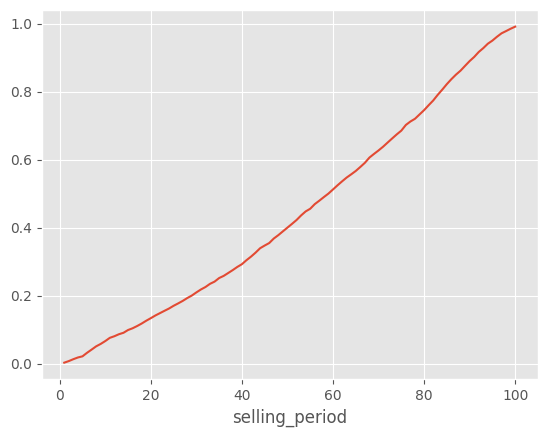

In [16]:
dfp_top_curves['mean_curve'] = """ADD CODE HERE""" 
dfp_top_curves['mean_curve'].plot()

In [17]:
dfp_top_curves

unique_selling_season_key,3UDGYU_57,3UDGYU_96,bh2y6f_1,bh2y6f_11,bh2y6f_14,bh2y6f_15,bh2y6f_19,bh2y6f_21,bh2y6f_22,bh2y6f_23,...,rPaVZC_80,rPaVZC_84,rPaVZC_90,rPaVZC_91,rPaVZC_92,rPaVZC_95,rPaVZC_97,rPaVZC_98,rPaVZC_99,mean_curve
selling_period,,,,,,,,,,,,,,,,,,,,,
1,0.01,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,...,0.00,0.01,0.00,0.02,0.01,0.00,0.00,0.00,0.00,0.003125
2,0.01,0.00,0.00,0.00,0.0,0.01,0.01,0.00,0.00,0.00,...,0.00,0.01,0.00,0.02,0.02,0.00,0.01,0.01,0.01,0.007750
3,0.01,0.00,0.00,0.00,0.0,0.02,0.02,0.01,0.01,0.00,...,0.00,0.01,0.01,0.02,0.05,0.00,0.01,0.02,0.04,0.013375
4,0.02,0.00,0.01,0.00,0.0,0.04,0.02,0.01,0.01,0.00,...,0.01,0.01,0.04,0.04,0.05,0.00,0.01,0.02,0.04,0.018375
5,0.02,0.00,0.01,0.00,0.0,0.04,0.02,0.01,0.02,0.00,...,0.01,0.01,0.04,0.04,0.05,0.01,0.02,0.02,0.04,0.021750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,1.00,0.98,0.92,0.98,1.0,0.98,1.00,1.00,0.88,0.90,...,0.94,0.88,0.96,0.92,0.85,0.98,1.00,1.00,0.99,0.961750
97,1.00,0.98,0.96,1.00,1.0,0.99,1.00,1.00,0.89,0.92,...,0.95,0.92,0.98,0.95,0.89,0.98,1.00,1.00,1.00,0.971875
98,1.00,0.98,0.99,1.00,1.0,0.99,1.00,1.00,0.89,0.92,...,0.98,0.92,0.99,0.98,0.92,0.98,1.00,1.00,1.00,0.978500


#### generate dict to describe the cruve at every 5th selling period in the selling season

In [18]:
target_sales_curve = {}
for t in  """ADD CODE HERE""" :
    target = {}
    target['cap_util'] = round(dfp_top_curves.loc[t,'mean_curve'],2)
    target['sold_seats'] =  """ADD CODE HERE""" 
    target_sales_curve[t] = target
    
target_sales_curve

{1: {'cap_util': 0.0, 'sold_seats': 0},
 6: {'cap_util': 0.03, 'sold_seats': 3},
 11: {'cap_util': 0.08, 'sold_seats': 6},
 16: {'cap_util': 0.1, 'sold_seats': 8},
 21: {'cap_util': 0.14, 'sold_seats': 11},
 26: {'cap_util': 0.18, 'sold_seats': 14},
 31: {'cap_util': 0.22, 'sold_seats': 17},
 36: {'cap_util': 0.26, 'sold_seats': 21},
 41: {'cap_util': 0.3, 'sold_seats': 24},
 46: {'cap_util': 0.36, 'sold_seats': 28},
 51: {'cap_util': 0.41, 'sold_seats': 33},
 56: {'cap_util': 0.47, 'sold_seats': 38},
 61: {'cap_util': 0.52, 'sold_seats': 42},
 66: {'cap_util': 0.58, 'sold_seats': 46},
 71: {'cap_util': 0.64, 'sold_seats': 51},
 76: {'cap_util': 0.7, 'sold_seats': 56},
 81: {'cap_util': 0.76, 'sold_seats': 61},
 86: {'cap_util': 0.84, 'sold_seats': 67},
 91: {'cap_util': 0.9, 'sold_seats': 72},
 96: {'cap_util': 0.96, 'sold_seats': 77}}

In [19]:
with open('target_sales_curve.pkl', "wb") as f:
    pickle.dump(target_sales_curve, f, protocol=pickle.HIGHEST_PROTOCOL)

## (2) implement the logic to follow this capacity utilization curve by controlling the price to stay close to the curve 

## price up -> slow down sales 
## price down -> increase sales

#### prepare given demand input for given competition and given selling season

In [20]:
with open('target_sales_curve.pkl', 'rb') as f:
            target_curve = pickle.load(f)
target_curve

{1: {'cap_util': 0.0, 'sold_seats': 0},
 6: {'cap_util': 0.03, 'sold_seats': 3},
 11: {'cap_util': 0.08, 'sold_seats': 6},
 16: {'cap_util': 0.1, 'sold_seats': 8},
 21: {'cap_util': 0.14, 'sold_seats': 11},
 26: {'cap_util': 0.18, 'sold_seats': 14},
 31: {'cap_util': 0.22, 'sold_seats': 17},
 36: {'cap_util': 0.26, 'sold_seats': 21},
 41: {'cap_util': 0.3, 'sold_seats': 24},
 46: {'cap_util': 0.36, 'sold_seats': 28},
 51: {'cap_util': 0.41, 'sold_seats': 33},
 56: {'cap_util': 0.47, 'sold_seats': 38},
 61: {'cap_util': 0.52, 'sold_seats': 42},
 66: {'cap_util': 0.58, 'sold_seats': 46},
 71: {'cap_util': 0.64, 'sold_seats': 51},
 76: {'cap_util': 0.7, 'sold_seats': 56},
 81: {'cap_util': 0.76, 'sold_seats': 61},
 86: {'cap_util': 0.84, 'sold_seats': 67},
 91: {'cap_util': 0.9, 'sold_seats': 72},
 96: {'cap_util': 0.96, 'sold_seats': 77}}

### load varriables as given in the duopoly p() function from our input data

In [21]:
# take first selling season
id = df_comp_details['unique_selling_season_key'].unique()[0]
df_select = df_comp_details[df_comp_details.unique_selling_season_key==id]

# define selling period
selling_period_in_current_season = 31

In [22]:
# get according deman object
demand_historical_in_current_season  = np.array(
            df_select[df_select.selling_period < selling_period_in_current_season]['demand']
)
demand_historical_in_current_season

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 2, 0, 2, 1, 1, 2, 0,
       0, 0, 0, 0, 0, 0, 1, 0])

In [23]:
# get according price object
prices_historical_in_current_season = [ 
    df_select[df_select.selling_period < selling_period_in_current_season]['price'], 
    df_select[df_select.selling_period < selling_period_in_current_season]['price_competitor'] ]
prices_historical_in_current_season  = np.array(prices_historical_in_current_season)

prices_historical_in_current_season

array([[66.4, 66.4, 66.4, 66.4, 66.4, 33.2, 33.2, 33.2, 33.2, 33.2, 16.6,
        16.6, 16.6, 16.6, 16.6, 11.9, 11.9, 11.9, 11.9, 11.9, 10.7, 10.7,
        10.7, 10.7, 10.7,  9. ,  9. ,  9. ,  9. ,  9. ],
       [56.1, 66.4, 66.4, 66.4, 66.4, 66.4, 33.2, 33.2, 33.2, 33.2, 33.2,
        16.6, 16.6, 16.6, 16.6, 16.6, 11.9, 11.9, 11.9, 11.9, 11.9, 10.7,
        10.7, 10.7, 10.7, 10.7,  9. ,  9. ,  9. ,  9. ]])

### logic

In [24]:
last_price = prices_historical_in_current_season[0][-1]
last_price

9.0

In [25]:
current_sold_seats = demand_historical_in_current_season.sum()
current_sold_seats

12

In [26]:
print("old price: %.2f" % last_price)

if selling_period_in_current_season in target_curve.keys():
    
    target = target_curve[selling_period_in_current_season]
    target_sales = target['sold_seats']
    
    print("sold seats: %d " % current_sold_seats)
    print("target sold seats: %d " % target_sales)
    
    delta_in_sales =  """ADD CODE HERE""" 
    print("percentage delta to target: %.2f" % delta_in_sales)
    
    ###
    # adjust price according to the delta
    price =  """ADD CODE HERE""" 
    print("new price: %.2f" % price)
    

old price: 9.00
sold seats: 12 
target sold seats: 17 
percentage delta to target: -0.29
new price: 20.00
